# 💻 第三课：代码建模实战 — 用 Python 构建真正的 Ontology

> **将 OPERA 框架落地为可运行的代码，使用 owlready2 构建符合 W3C 标准的 OWL 本体。**

### 📋 学习目标

| # | 目标 | 状态 |
|---|------|------|
| 1 | 掌握 owlready2 库的核心 API | ☐ |
| 2 | 用代码实现 OPERA 五步建模 | ☐ |
| 3 | 运行推理引擎自动发现隐含知识 | ☐ |
| 4 | 导出标准 OWL 文件并查询本体 | ☐ |

### 前置要求
- 完成第一课（五大构件）和第二课（OPERA 框架）
- 已安装 `owlready2`、`rdflib` 库

---
## 🔧 Part 1：环境准备与工具认识

In [1]:
# 环境检查
import sys
print(f"Python 版本: {sys.version}")

try:
    import owlready2
    print(f"owlready2 版本: {owlready2.VERSION}")
except ImportError:
    print("❌ 请先安装: pip install owlready2")

try:
    import rdflib
    print(f"rdflib 版本: {rdflib.__version__}")
except ImportError:
    print("❌ 请先安装: pip install rdflib")

print("\n✅ 环境就绪！")

Python 版本: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
owlready2 版本: 0.50
rdflib 版本: 7.6.0

✅ 环境就绪！


### 🤔 为什么用 owlready2？

| 特性 | owlready2 | rdflib | Protégé |
|------|-----------|--------|----------|
| 语言 | Python | Python | Java/GUI |
| 学习曲线 | ⭐⭐ 低 | ⭐⭐⭐ 中 | ⭐⭐⭐⭐ 高 |
| 推理能力 | ✅ 内置推理引擎 | ❌ 需要额外配置 | ✅ 完整推理 |
| Python 风格 | ✅ 像操作普通类 | ❌ 三元组操作 | N/A |
| OWL 标准 | ✅ 完整支持 | ✅ RDF/OWL | ✅ 完整支持 |

> **owlready2 的杀手级优势：可以像写普通 Python 类一样来定义 Ontology！**

---
## 📦 Part 2：O — 用代码定义对象类型 (Object Types)

我们选择「智能宠物医院」作为贯穿本课的实战场景。

> **场景目标：** 构建一个宠物医院本体，能够管理动物、兽医、诊断、治疗，并自动推理潜在风险。

In [2]:
# 📦 Step O：定义对象类型（类层次结构）

from owlready2 import *

# 创建一个新的 Ontology（本体）
onto = get_ontology("http://example.org/pet-hospital.owl")

with onto:
    # ===== 顶层类 =====
    class Animal(Thing):
        """所有动物的基类"""
        pass
    
    class Person(Thing):
        """人"""
        pass
    
    class MedicalRecord(Thing):
        """医疗记录"""
        pass
    
    class Medication(Thing):
        """药物"""
        pass
    
    # ===== 动物子类 =====
    class Dog(Animal):
        """犬类"""
        pass
    
    class Cat(Animal):
        """猫类"""
        pass
    
    class Bird(Animal):
        """鸟类"""
        pass
    
    # ===== 人的子类 =====
    class Veterinarian(Person):
        """兽医"""
        pass
    
    class Owner(Person):
        """宠物主人"""
        pass
    
    # ===== 医疗子类 =====
    class Diagnosis(MedicalRecord):
        """诊断"""
        pass
    
    class Treatment(MedicalRecord):
        """治疗方案"""
        pass

# 查看类层次
print("📦 宠物医院本体 — 类层次结构：")
print("="*50)
for cls in onto.classes():
    parents = [p.name for p in cls.is_a if hasattr(p, 'name')]
    parent_str = f" (继承自 {', '.join(parents)})" if parents else " (顶层)"
    print(f"  📦 {cls.name}{parent_str}")

print(f"\n✅ 共定义了 {len(list(onto.classes()))} 个类")

📦 宠物医院本体 — 类层次结构：
  📦 Animal (继承自 Thing)
  📦 Person (继承自 Thing)
  📦 MedicalRecord (继承自 Thing)
  📦 Medication (继承自 Thing)
  📦 Dog (继承自 Animal)
  📦 Cat (继承自 Animal)
  📦 Bird (继承自 Animal)
  📦 Veterinarian (继承自 Person)
  📦 Owner (继承自 Person)
  📦 Diagnosis (继承自 MedicalRecord)
  📦 Treatment (继承自 MedicalRecord)

✅ 共定义了 11 个类


> 💡 **注意 `with onto:` 的用法** — 在这个上下文中定义的所有类都属于该本体。
> 这就像在数据库中"选择使用某个 schema"。

---
## 📋 Part 3：P — 用代码定义属性 (Properties)

owlready2 中有两种属性：
- **DataProperty** — 值为基本数据类型（字符串、数字等）
- **ObjectProperty** — 值为另一个本体对象（在 OPERA 中归入 R 关系，这里先一起定义）

In [3]:
# 📋 Step P：定义属性

with onto:
    # ===== 数据属性 (Data Properties) =====
    
    class has_name(DataProperty):
        """名字"""
        domain = [Thing]       # 适用于所有对象
        range  = [str]         # 值类型：字符串
    
    class has_age(DataProperty):
        """年龄（岁）"""
        domain = [Animal]
        range  = [int]
    
    class has_weight(DataProperty):
        """体重（kg）"""
        domain = [Animal]
        range  = [float]
    
    class is_vaccinated(DataProperty):
        """是否已接种疫苗"""
        domain = [Animal]
        range  = [bool]
    
    class has_specialty(DataProperty):
        """专长领域"""
        domain = [Veterinarian]
        range  = [str]
    
    class has_symptom(DataProperty):
        """症状描述"""
        domain = [Diagnosis]
        range  = [str]
    
    class has_severity(DataProperty):
        """严重程度 1-5"""
        domain = [Diagnosis]
        range  = [int]

    # ===== 对象属性 (Object Properties) — 即关系(R) =====

    class owned_by(ObjectProperty):
        """动物的主人"""
        domain = [Animal]
        range  = [Owner]
    
    class treated_by(ObjectProperty):
        """被哪位兽医治疗"""
        domain = [Animal]
        range  = [Veterinarian]
    
    class has_diagnosis(ObjectProperty):
        """有哪些诊断"""
        domain = [Animal]
        range  = [Diagnosis]
    
    class requires_treatment(ObjectProperty):
        """诊断需要的治疗"""
        domain = [Diagnosis]
        range  = [Treatment]

    class allergic_to(ObjectProperty):
        """对某药物过敏"""
        domain = [Animal]
        range  = [Medication]

    class uses_medication(ObjectProperty):
        """治疗使用某药物"""
        domain = [Treatment]
        range  = [Medication]

# 查看属性
print("📋 数据属性 (Data Properties):")
for p in onto.data_properties():
    d = [c.name for c in p.domain] if p.domain else ['Any']
    r = [str(c.__name__) if hasattr(c, '__name__') else str(c) for c in p.range] if p.range else ['Any']
    print(f"  · {p.name}: {', '.join(d)} → {', '.join(r)}")

print(f"\n🔗 对象属性 (Object Properties = 关系):")
for p in onto.object_properties():
    d = [c.name for c in p.domain] if p.domain else ['Any']
    r = [c.name for c in p.range] if p.range else ['Any']
    print(f"  · {p.name}: {', '.join(d)} → {', '.join(r)}")

print(f"\n✅ 共 {len(list(onto.data_properties()))} 个数据属性，{len(list(onto.object_properties()))} 个对象属性")

📋 数据属性 (Data Properties):
  · has_name: Thing → str
  · has_age: Animal → int
  · has_weight: Animal → float
  · is_vaccinated: Animal → bool
  · has_specialty: Veterinarian → str
  · has_symptom: Diagnosis → str
  · has_severity: Diagnosis → int

🔗 对象属性 (Object Properties = 关系):
  · owned_by: Animal → Owner
  · treated_by: Animal → Veterinarian
  · has_diagnosis: Animal → Diagnosis
  · requires_treatment: Diagnosis → Treatment
  · allergic_to: Animal → Medication
  · uses_medication: Treatment → Medication

✅ 共 7 个数据属性，6 个对象属性


---
## 🏷️ Part 4：创建实例 — 往本体里填充数据

类是"蓝图"，实例是"按蓝图造出来的具体东西"。
现在让我们给宠物医院"招聘员工"、"接收宠物"。

In [4]:
# 🏷️ 创建实例（个体）

with onto:
    # === 创建药物 ===
    penicillin = Medication("penicillin")
    penicillin.has_name = ["青霉素"]
    
    amoxicillin = Medication("amoxicillin")
    amoxicillin.has_name = ["阿莫西林"]
    
    painkiller = Medication("painkiller")
    painkiller.has_name = ["止痛药"]
    
    # === 创建兽医 ===
    dr_li = Veterinarian("dr_li")
    dr_li.has_name = ["李医生"]
    dr_li.has_specialty = ["骨科"]
    
    dr_wang = Veterinarian("dr_wang")
    dr_wang.has_name = ["王医生"]
    dr_wang.has_specialty = ["内科"]
    
    # === 创建主人 ===
    zhang_san = Owner("zhang_san")
    zhang_san.has_name = ["张三"]
    
    li_si = Owner("li_si")
    li_si.has_name = ["李四"]
    
    # === 创建宠物 ===
    wangcai = Dog("wangcai")
    wangcai.has_name = ["旺财"]
    wangcai.has_age = [3]
    wangcai.has_weight = [12.5]
    wangcai.is_vaccinated = [True]
    wangcai.owned_by = [zhang_san]
    wangcai.treated_by = [dr_li]
    wangcai.allergic_to = [penicillin]  # ⚠️ 旺财对青霉素过敏！
    
    mimi = Cat("mimi")
    mimi.has_name = ["咪咪"]
    mimi.has_age = [1]
    mimi.has_weight = [4.2]
    mimi.is_vaccinated = [False]  # ⚠️ 未接种疫苗
    mimi.owned_by = [li_si]
    mimi.treated_by = [dr_wang]
    
    dahuang = Dog("dahuang")
    dahuang.has_name = ["大黄"]
    dahuang.has_age = [8]
    dahuang.has_weight = [28.0]
    dahuang.is_vaccinated = [True]
    dahuang.owned_by = [zhang_san]
    
    # === 创建诊断 ===
    diag1 = Diagnosis("diag_wangcai_fracture")
    diag1.has_name = ["旺财的骨折诊断"]
    diag1.has_symptom = ["右前腿骨折"]
    diag1.has_severity = [4]
    wangcai.has_diagnosis = [diag1]
    
    # === 创建治疗方案 ===
    treat1 = Treatment("treat_fracture_surgery")
    treat1.has_name = ["骨折手术"]
    treat1.uses_medication = [penicillin, painkiller]  # ⚠️ 包含青霉素！
    diag1.requires_treatment = [treat1]

# 展示所有实例
print("🏷️ 宠物医院已录入数据：")
print("=" * 50)
for cls_name in ["Dog", "Cat", "Veterinarian", "Owner", "Medication", "Diagnosis", "Treatment"]:
    cls = onto[cls_name]
    instances = list(cls.instances())
    if instances:
        names = [i.has_name[0] if i.has_name else i.name for i in instances]
        print(f"  {cls_name}: {', '.join(names)}")

print(f"\n✅ 共创建了 {len(list(onto.individuals()))} 个实例")

🏷️ 宠物医院已录入数据：
  Dog: 旺财, 大黄
  Cat: 咪咪
  Veterinarian: 李医生, 王医生
  Owner: 张三, 李四
  Medication: 青霉素, 阿莫西林, 止痛药
  Diagnosis: 旺财的骨折诊断
  Treatment: 骨折手术

✅ 共创建了 12 个实例


---
## ⚡ Part 5：E — 事件与动作（用函数实现业务逻辑）

> 在 OWL 标准中没有原生的 "Action" 概念，但我们可以用 Python 函数结合 Ontology 查询来实现。
> 这也是 Palantir 的做法——Ontology 定义数据模型，Action 函数在模型上执行操作。

In [5]:
# ⚡ Step E：事件与动作

def check_allergy(animal, treatment):
    """⚠️ 过敏检查动作 — 检测治疗方案是否含有动物过敏的药物"""
    animal_name = animal.has_name[0] if animal.has_name else animal.name
    treat_name = treatment.has_name[0] if treatment.has_name else treatment.name
    
    allergies = set(animal.allergic_to)
    medications = set(treatment.uses_medication)
    conflicts = allergies & medications
    
    print(f"\n🔍 过敏检查：{animal_name} × {treat_name}")
    print(f"   动物过敏药物：{[m.has_name[0] for m in allergies] if allergies else '无'}")
    print(f"   治疗用药：{[m.has_name[0] for m in medications]}")
    
    if conflicts:
        conflict_names = [m.has_name[0] for m in conflicts]
        print(f"   ❌ 危险！药物冲突：{conflict_names}")
        print(f"   ⚠️ 须更换不含 {conflict_names} 的替代方案！")
        return False
    else:
        print(f"   ✅ 安全，无过敏冲突")
        return True


def vaccination_alert(onto):
    """🔔 疫苗接种提醒事件 — 扫描所有未接种疫苗的动物"""
    print("\n🔔 疫苗接种检查报告：")
    print("=" * 40)
    unvaccinated = []
    
    for animal in onto.Animal.instances():
        name = animal.has_name[0] if animal.has_name else animal.name
        if animal.is_vaccinated and not animal.is_vaccinated[0]:
            owner_name = animal.owned_by[0].has_name[0] if animal.owned_by else "未知"
            unvaccinated.append((name, type(animal).__name__, owner_name))
            print(f"  ⚠️ {name} ({type(animal).__name__}) — 主人：{owner_name} — 未接种！")
        else:
            print(f"  ✅ {name} — 已接种")
    
    if unvaccinated:
        print(f"\n  📋 需通知 {len(unvaccinated)} 位主人安排疫苗接种")
    else:
        print(f"\n  🎉 所有动物均已接种疫苗")
    return unvaccinated


# === 执行动作 ===
print("⚡ 执行 Action: 过敏检查")
check_allergy(wangcai, treat1)

print("\n" + "─" * 50)
print("⚡ 执行 Event: 疫苗扫描")
vaccination_alert(onto)

⚡ 执行 Action: 过敏检查

🔍 过敏检查：旺财 × 骨折手术
   动物过敏药物：['青霉素']
   治疗用药：['青霉素', '止痛药']
   ❌ 危险！药物冲突：['青霉素']
   ⚠️ 须更换不含 ['青霉素'] 的替代方案！

──────────────────────────────────────────────────
⚡ 执行 Event: 疫苗扫描

🔔 疫苗接种检查报告：
  ✅ 旺财 — 已接种
  ✅ 大黄 — 已接种
  ⚠️ 咪咪 (Cat) — 主人：李四 — 未接种！

  📋 需通知 1 位主人安排疫苗接种


[('咪咪', 'Cat', '李四')]

> **💡 关键认知：** 看到了吗？旺财的骨折治疗方案里包含青霉素，但旺财对青霉素过敏！
> 
> 如果没有 Ontology 的关系链（Animal → allergic_to → Medication ← uses_medication ← Treatment），
> 这个风险可能要到实际用药时才被发现。**Ontology + 公理 = 提前预防。**

---
## ⚖️ Part 6：A — 用代码实现公理（推理规则）

owlready2 支持用 SWRL (Semantic Web Rule Language) 规则来定义公理，
也可以使用类限定（Restriction）来表达约束。

In [6]:
# ⚖️ Step A：定义公理 — 使用类限定 (Restrictions)

with onto:
    # 公理 1：Dog 和 Cat 互斥（一个个体不能同时是 Dog 又是 Cat）
    AllDisjoint([Dog, Cat, Bird])
    
    # 公理 2：高危动物定义 — 用 Python 函数实现推理（因为 SWRL 语法在 notebook 中不易调试）

def run_custom_reasoning(onto):
    """自定义推理引擎——基于公理扫描所有个体"""
    print("\n🤖 自定义推理引擎运行中...")
    print("=" * 55)
    findings = []
    
    for animal in onto.Animal.instances():
        name = animal.has_name[0] if animal.has_name else animal.name
        
        # 推理规则 1: 大型犬标记
        if isinstance(animal, onto.Dog) and animal.has_weight and animal.has_weight[0] > 20:
            msg = f"🐕 {name}: 大型犬 ({animal.has_weight[0]}kg)，需大型犬候诊区"
            findings.append(msg)
            print(f"  {msg}")
        
        # 推理规则 2: 老年动物标记
        if animal.has_age and animal.has_age[0] >= 7:
            msg = f"👴 {name}: 老年动物 ({animal.has_age[0]}岁)，建议全面体检"
            findings.append(msg)
            print(f"  {msg}")
        
        # 推理规则 3: 未接种 + 年幼 = 高危
        if (animal.is_vaccinated and not animal.is_vaccinated[0] 
            and animal.has_age and animal.has_age[0] <= 1):
            msg = f"🚨 {name}: 高危！年幼({animal.has_age[0]}岁)且未接种疫苗"
            findings.append(msg)
            print(f"  {msg}")
        
        # 推理规则 4: 过敏药物与治疗冲突
        if animal.allergic_to and animal.has_diagnosis:
            for diag in animal.has_diagnosis:
                if diag.requires_treatment:
                    for treat in diag.requires_treatment:
                        conflicts = set(animal.allergic_to) & set(treat.uses_medication)
                        if conflicts:
                            c_names = [m.has_name[0] for m in conflicts]
                            msg = f"💊 {name}: 药物过敏冲突！{c_names} 存在于治疗方案中"
                            findings.append(msg)
                            print(f"  {msg}")
    
    print(f"\n📊 推理完成，共发现 {len(findings)} 条结果")
    return findings

# 运行推理
results = run_custom_reasoning(onto)


🤖 自定义推理引擎运行中...
  💊 旺财: 药物过敏冲突！['青霉素'] 存在于治疗方案中
  🐕 大黄: 大型犬 (28.0kg)，需大型犬候诊区
  👴 大黄: 老年动物 (8岁)，建议全面体检
  🚨 咪咪: 高危！年幼(1岁)且未接种疫苗

📊 推理完成，共发现 4 条结果


> **🎯 推理结果解读：**
> - 大黄是大型犬（28kg）且已经 8 岁（老年），两条规则都命中
> - 咪咪只有 1 岁但未接种疫苗，属于高危
> - 旺财的治疗方案含青霉素，但它对青霉素过敏 — **这是最危险的发现！**
>
> 这些发现全部是**机器自动推理**出来的，不需要人工逐个检查。

---
## 💾 Part 7：导出与查询

把我们构建的本体保存为标准 OWL 文件，并演示如何进行结构化查询。

In [7]:
# 💾 导出为 OWL 文件
import os

output_dir = os.path.dirname(os.path.abspath("__file__"))
owl_path = os.path.join(output_dir, "pet_hospital.owl")

onto.save(file=owl_path, format="rdfxml")
print(f"💾 本体已保存至：{owl_path}")

# 查看文件大小
size_kb = os.path.getsize(owl_path) / 1024
print(f"   文件大小：{size_kb:.1f} KB")

# 预览 OWL 文件内容（前30行）
print(f"\n📄 OWL 文件预览（前20行）：")
print("-" * 60)
with open(owl_path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 20:
            print("  ...（更多内容省略）")
            break
        print(f"  {line.rstrip()}")

💾 本体已保存至：c:\Users\Admin\Desktop\practice\ontology\ontology-notebooks\pet_hospital.owl
   文件大小：7.8 KB

📄 OWL 文件预览（前20行）：
------------------------------------------------------------
  <?xml version="1.0"?>
  <rdf:RDF xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
           xmlns:xsd="http://www.w3.org/2001/XMLSchema#"
           xmlns:rdfs="http://www.w3.org/2000/01/rdf-schema#"
           xmlns:owl="http://www.w3.org/2002/07/owl#"
           xml:base="http://example.org/pet-hospital.owl"
           xmlns="http://example.org/pet-hospital.owl#">
  
  <owl:Ontology rdf:about="http://example.org/pet-hospital.owl"/>
  
  <owl:ObjectProperty rdf:about="#owned_by">
    <rdfs:domain rdf:resource="#Animal"/>
    <rdfs:range rdf:resource="#Owner"/>
  </owl:ObjectProperty>
  
  <owl:ObjectProperty rdf:about="#treated_by">
    <rdfs:domain rdf:resource="#Animal"/>
    <rdfs:range rdf:resource="#Veterinarian"/>
  </owl:ObjectProperty>
  
  ...（更多内容省略）


In [8]:
# 🔍 Ontology 查询示例

print("🔍 常用查询示例：")
print("=" * 55)

# 查询 1：所有狗
dogs = list(onto.Dog.instances())
print(f"\n🐶 所有 Dog 实例：")
for d in dogs:
    name = d.has_name[0] if d.has_name else d.name
    age = d.has_age[0] if d.has_age else '?'
    weight = d.has_weight[0] if d.has_weight else '?'
    print(f"   · {name}, {age}岁, {weight}kg")

# 查询 2：张三的所有宠物
print(f"\n👤 张三的所有宠物：")
for animal in onto.Animal.instances():
    if zhang_san in animal.owned_by:
        name = animal.has_name[0] if animal.has_name else animal.name
        cls = type(animal).__name__
        print(f"   · {name} ({cls})")

# 查询 3：李医生负责的动物
print(f"\n👨‍⚕️ 李医生负责治疗的动物：")
for animal in onto.Animal.instances():
    if dr_li in animal.treated_by:
        name = animal.has_name[0] if animal.has_name else animal.name
        print(f"   · {name}")

# 查询 4：有诊断的动物及其诊断详情
print(f"\n📋 有诊断记录的动物：")
for animal in onto.Animal.instances():
    if animal.has_diagnosis:
        name = animal.has_name[0] if animal.has_name else animal.name
        for diag in animal.has_diagnosis:
            symptom = diag.has_symptom[0] if diag.has_symptom else '?'
            severity = diag.has_severity[0] if diag.has_severity else '?'
            print(f"   · {name}: {symptom} (严重程度: {severity}/5)")
            if diag.requires_treatment:
                for t in diag.requires_treatment:
                    t_name = t.has_name[0] if t.has_name else t.name
                    meds = [m.has_name[0] for m in t.uses_medication] if t.uses_medication else []
                    print(f"     → 治疗: {t_name}, 用药: {meds}")

print("\n✅ 这就是 Ontology 的结构化查询——沿着关系链精确检索！")

🔍 常用查询示例：

🐶 所有 Dog 实例：
   · 旺财, 3岁, 12.5kg
   · 大黄, 8岁, 28.0kg

👤 张三的所有宠物：
   · 旺财 (Dog)
   · 大黄 (Dog)

👨‍⚕️ 李医生负责治疗的动物：
   · 旺财

📋 有诊断记录的动物：
   · 旺财: 右前腿骨折 (严重程度: 4/5)
     → 治疗: 骨折手术, 用药: ['青霉素', '止痛药']

✅ 这就是 Ontology 的结构化查询——沿着关系链精确检索！


---
## 🔄 Part 8：用 rdflib 进行 SPARQL 查询

> SPARQL 是本体和知识图谱的标准查询语言（类似于 SQL 对于数据库）。
> 它能穿越多层关系链进行复杂查询。

In [9]:
# 🔄 用 rdflib 加载本体并执行 SPARQL 查询

import rdflib

g = rdflib.Graph()
g.parse(owl_path, format="xml")
print(f"📊 知识图谱已加载，共 {len(g)} 个三元组(triples)\n")

# SPARQL 查询 1：列出所有动物及其主人
query1 = """
PREFIX onto: <http://example.org/pet-hospital.owl#>

SELECT ?animal_name ?owner_name ?animal_type
WHERE {
    ?animal onto:has_name ?animal_name .
    ?animal onto:owned_by ?owner .
    ?owner onto:has_name ?owner_name .
    ?animal a ?animal_type .
    FILTER (?animal_type IN (onto:Dog, onto:Cat, onto:Bird))
}
"""

print("🔍 SPARQL 查询：所有动物及主人")
print("-" * 45)
results = g.query(query1)
for row in results:
    animal_type = str(row.animal_type).split('#')[-1]
    print(f"  {row.animal_name} ({animal_type}) → 主人: {row.owner_name}")

# SPARQL 查询 2：找出过敏药物冲突（关系链查询）
query2 = """
PREFIX onto: <http://example.org/pet-hospital.owl#>

SELECT ?animal_name ?drug_name
WHERE {
    ?animal onto:allergic_to ?drug .
    ?animal onto:has_name ?animal_name .
    ?animal onto:has_diagnosis ?diag .
    ?diag onto:requires_treatment ?treat .
    ?treat onto:uses_medication ?drug .
    ?drug onto:has_name ?drug_name .
}
"""

print(f"\n🚨 SPARQL 查询：过敏药物冲突")
print("-" * 45)
results2 = g.query(query2)
found = False
for row in results2:
    found = True
    print(f"  ❌ {row.animal_name} 的治疗方案包含其过敏药物：{row.drug_name}")
if not found:
    print("  ✅ 未发现冲突")

print("\n💡 SPARQL 能穿越 5 层关系链：animal → diagnosis → treatment → medication ← allergic_to")
print("   这在传统 SQL 中需要多次 JOIN，而 SPARQL 天然支持图遍历。")

📊 知识图谱已加载，共 129 个三元组(triples)

🔍 SPARQL 查询：所有动物及主人
---------------------------------------------
  旺财 (Dog) → 主人: 张三
  大黄 (Dog) → 主人: 张三
  咪咪 (Cat) → 主人: 李四

🚨 SPARQL 查询：过敏药物冲突
---------------------------------------------
  ❌ 旺财 的治疗方案包含其过敏药物：青霉素

💡 SPARQL 能穿越 5 层关系链：animal → diagnosis → treatment → medication ← allergic_to
   这在传统 SQL 中需要多次 JOIN，而 SPARQL 天然支持图遍历。


---
## 📊 Part 9：可视化本体结构

用 networkx + matplotlib 生成一张本体关系图，直观看到整个知识网络。

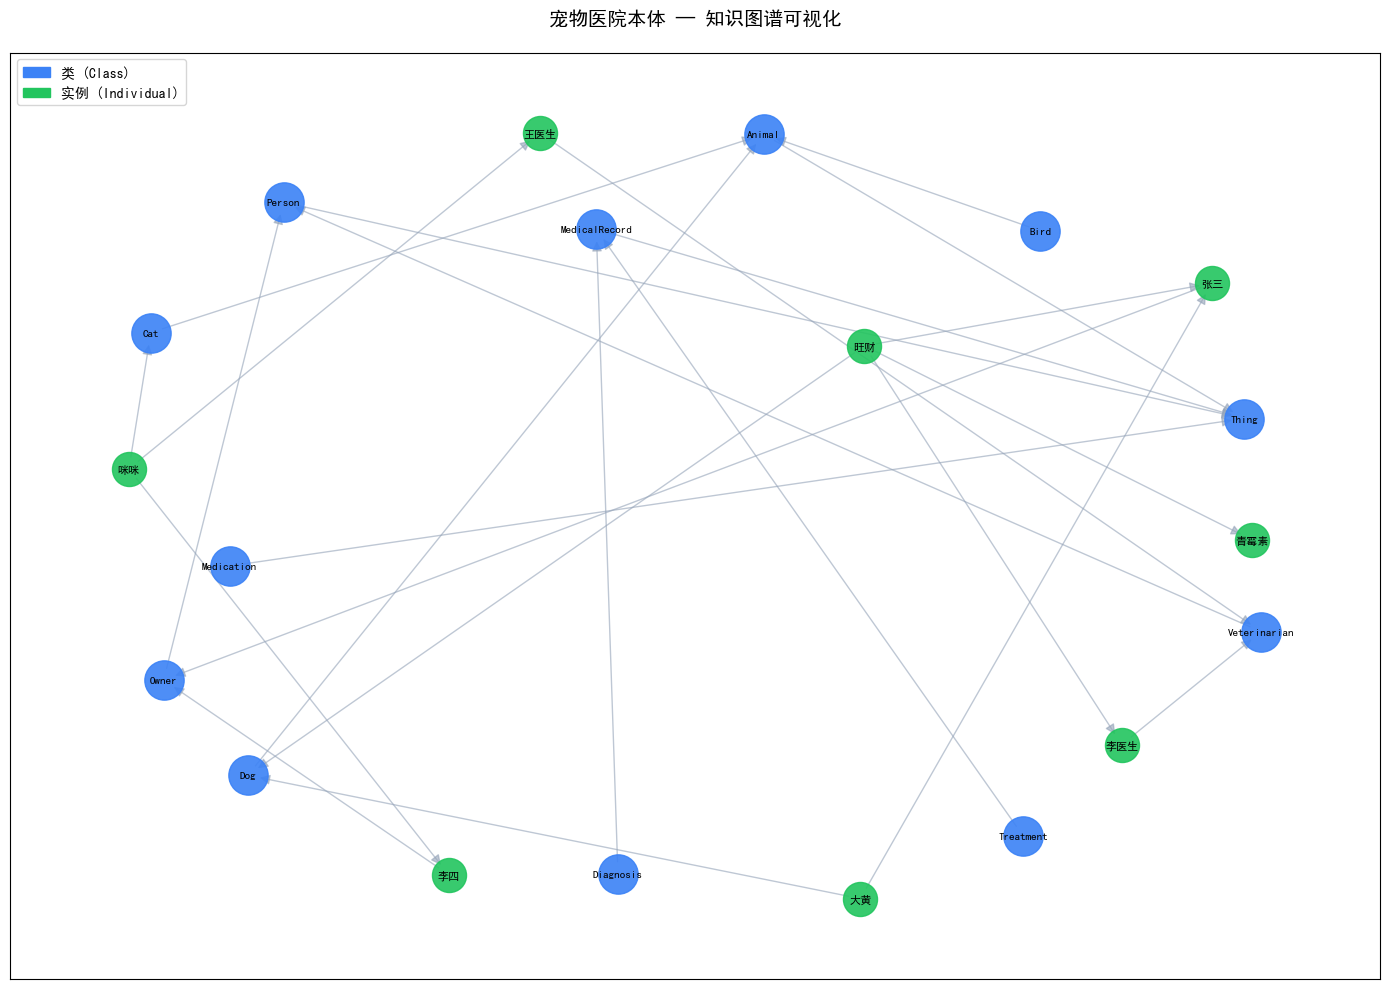


📊 图谱包含 20 个节点，24 条边


In [10]:
# 📊 可视化本体关系图

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

G = nx.DiGraph()

# 添加类层次（蓝色）
class_edges = [
    ("Animal", "Thing"), ("Dog", "Animal"), ("Cat", "Animal"), ("Bird", "Animal"),
    ("Person", "Thing"), ("Veterinarian", "Person"), ("Owner", "Person"),
    ("MedicalRecord", "Thing"), ("Diagnosis", "MedicalRecord"), ("Treatment", "MedicalRecord"),
    ("Medication", "Thing")
]
for child, parent in class_edges:
    G.add_edge(child, parent, label="is-a", style="solid")

# 添加实例关系（绿色）
instance_edges = [
    ("旺财", "Dog"), ("咪咪", "Cat"), ("大黄", "Dog"),
    ("李医生", "Veterinarian"), ("王医生", "Veterinarian"),
    ("张三", "Owner"), ("李四", "Owner"),
]
for inst, cls in instance_edges:
    G.add_edge(inst, cls, label="instance-of", style="dashed")

# 添加关系（红色）
relation_edges = [
    ("旺财", "张三", "owned_by"), ("旺财", "李医生", "treated_by"),
    ("咪咪", "李四", "owned_by"), ("咪咪", "王医生", "treated_by"),
    ("大黄", "张三", "owned_by"),
    ("旺财", "青霉素", "allergic_to"),
]
for src, tgt, label in relation_edges:
    G.add_edge(src, tgt, label=label, style="dotted")

# 布局
pos = nx.spring_layout(G, k=2.0, iterations=50, seed=42)

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# 根据节点类型着色
class_nodes = ["Thing", "Animal", "Dog", "Cat", "Bird", "Person", "Veterinarian", 
               "Owner", "MedicalRecord", "Diagnosis", "Treatment", "Medication"]
instance_nodes = ["旺财", "咪咪", "大黄", "李医生", "王医生", "张三", "李四", "青霉素"]

nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes if n in class_nodes],
                       node_color='#3b82f6', node_size=800, alpha=0.9, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=[n for n in G.nodes if n in instance_nodes],
                       node_color='#22c55e', node_size=600, alpha=0.9, ax=ax)

nx.draw_networkx_labels(G, pos, font_size=8, font_family='SimHei', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='#94a3b8', arrows=True, 
                       arrowsize=15, ax=ax, alpha=0.6)

# 图例
import matplotlib.patches as mpatches
legend_items = [
    mpatches.Patch(color='#3b82f6', label='类 (Class)'),
    mpatches.Patch(color='#22c55e', label='实例 (Individual)'),
]
ax.legend(handles=legend_items, loc='upper left', fontsize=10)

ax.set_title('宠物医院本体 — 知识图谱可视化', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"\n📊 图谱包含 {G.number_of_nodes()} 个节点，{G.number_of_edges()} 条边")

---
## 📝 第三课小结

### ✅ 你已经学会了：

- [x] 用 **owlready2** 创建 Ontology 并定义类层次
- [x] 定义 **DataProperty** 和 **ObjectProperty**
- [x] 创建实例并设置属性和关系
- [x] 用 Python 函数实现 **Action 和 Event**（过敏检查、疫苗提醒）
- [x] 用公理和推理规则**自动发现潜在风险**
- [x] 导出为 **OWL/RDF 标准文件**
- [x] 用 **SPARQL** 进行关系链查询
- [x] 用 **networkx** 可视化本体结构

### 🔜 下一课预告

> **第四课：多领域案例** — 将 OPERA 框架应用到智慧医院、电商供应链、智慧交通、企业知识管理四大场景，举一反三。

In [ ]:
# 📝 第三课小测验

questions = [
    {
        "q": "owlready2 中的 DataProperty 和 ObjectProperty 有什么区别？",
        "options": {
            "A": "没有区别，可以互换",
            "B": "DataProperty 的值是基本类型(str/int等)，ObjectProperty 的值是另一个本体对象",
            "C": "DataProperty 是只读的，ObjectProperty 可以修改",
            "D": "DataProperty 存在数据库中，ObjectProperty 存在文件中"
        },
        "answer": "B",
        "explain": "DataProperty 的 range 是 str/int/float 等基本类型，ObjectProperty 的 range 是另一个 Class。"
    },
    {
        "q": "旺财的过敏冲突是如何被发现的？",
        "options": {
            "A": "医生手动检查病历",
            "B": "通过关系链推理：animal → allergic_to → medication ← uses_medication ← treatment",
            "C": "通过关键词搜索",
            "D": "通过数据库 SQL 查询"
        },
        "answer": "B",
        "explain": "Ontology 的推理穿越了多层关系链，自动发现了药物过敏冲突。这正是 Ontology 推理的威力。"
    },
    {
        "q": "SPARQL 相对于 SQL 的核心优势是什么？",
        "options": {
            "A": "执行速度更快",
            "B": "语法更简单",
            "C": "天然支持图遍历和关系链查询，不需要 JOIN",
            "D": "支持更多数据类型"
        },
        "answer": "C",
        "explain": "SPARQL 在图结构上进行模式匹配，穿越关系链无需显式 JOIN，这是知识图谱查询的核心优势。"
    }
]

score = 0
print("📝 第三课小测验（共 3 题）\n")
for i, q in enumerate(questions, 1):
    print(f"第 {i} 题：{q['q']}")
    for k, v in q["options"].items():
        print(f"  {k}. {v}")
    ans = input("你的答案 (A/B/C/D)：").strip().upper()
    if ans == q["answer"]:
        print(f"✅ 正确！{q['explain']}\n")
        score += 1
    else:
        print(f"❌ 正确答案是 {q['answer']}。{q['explain']}\n")

print(f"🏆 得分：{score}/3")
if score == 3:
    print("🎉 完美！你已经可以用代码构建 Ontology 了！")
print("\n➡️ 下一课我们将把 OPERA 应用到四个不同行业！")